# CC-WBT-AI — Input Pipeline

Workflow: set inputs → write to files → run engine → read outputs

In [1]:
import sys, os
import openpyxl as _xl
from dotenv import load_dotenv
load_dotenv()
 
_cwd = os.path.abspath('')
if os.path.exists(os.path.join(_cwd, 'backend')):
    ROOT = _cwd
elif os.path.exists(os.path.join(_cwd, '..', 'backend')):
    ROOT = os.path.dirname(_cwd)
else:
    raise FileNotFoundError("Cannot find the backend folder")
 
BACKEND   = os.path.join(ROOT, 'backend')
NOTEBOOKS = os.path.join(ROOT, 'notebooks')
sys.path.insert(0, BACKEND)
sys.path.insert(0, NOTEBOOKS)

from pipeline_helpers import PipelineIO
from optimizer import run_optimization
print('Setup OK')

c:\Users\agarr\OneDrive\Escritorio\IIT\CC-WBT-AI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup OK


## 1. Model and technologies

In [2]:
COUNTRY    = 'Mozambique'
MODEL      = 'CleanStep'
TECHS      = ['Electricity', 'LPG']
START_YEAR = 2023
END_YEAR   = 2034
YEARS      = list(range(START_YEAR, END_YEAR + 1))
 
pio = PipelineIO(backend=BACKEND, country=COUNTRY, model=MODEL, techs=TECHS, start_year=START_YEAR, end_year=END_YEAR)
pio.ensure_model_exists()

Model CleanStep exists with the correct technologies.


## 2. Country-level inputs

In [3]:
# config
TAX_RATE  = 28
INFLATION = 5
 
# fuel financial inputs
FUEL_FIN = {
    'Electricity': {
        'NTL':      [5]*12,
        'DAYS_REC': [30]*12,
        'DAYS_PAY': [30]*12,
    },
    'LPG': {
        'NTL':      [5]*12,
        'DAYS_REC': [30]*12,
        'DAYS_PAY': [30]*12,
    },
}
 
# carbon credits (fuel-financial-inputs)
CC_CO2_CERT  = [0]*12
CC_LIQUIDITY = [0]*12
CC_PRICE_TON = [0]*12
CC_NUM_YEARS = 0
 
print('Country-level inputs defined.')

Country-level inputs defined.


## 3. Model-level inputs

In [4]:
# technoeconomic-inputs - Electricity (GRID/OFF-GRID)
TECHNO_ELEC = {
    'Electricity & E-Cooking': {
        'GRID': {
            'Demand':             [1473.6, 1616.8, 1793.2, 1954.5, 3101.6, 2235.1, 2355.9, 2518.5, 1659.5, 2786.4, 2900, 3001],
            'CAPEX - Growth':     [257.3,  324.6,  321.4,  318.2, 315, 311.8, 382, 451.1, 446.6, 442.1, 437.7, 290.8],
            'CAPEX - Maintenance':[0]*12,
            'OPEX':               [48.2,   54.6,   62.2,   69.6, 77, 84.1, 91.1, 102.2, 112.7, 123, 133.1, 143],
            'D&A':                35,
        },
        'OFF-GRID': {
            'Demand':             [368.4, 379.3, 393.6, 400.3, 400.3, 394.4, 383.5, 376.3, 362.7, 344.4, 322.2, 296.8],
            'CAPEX - Growth':     [39.5,  50.3, 49.8, 49.3, 48.8, 48.4, 15.4, -17.1, -16.9, -16.8, -16.6, -1.7],
            'CAPEX - Maintenance':[0]*12,
            'OPEX':               [56.1,  64.7, 74.9, 84.8, 94.5, 104, 113.4, 111.6, 105.1, 98.8, 92.6, 86.4],
            'D&A':                25,
        },
    },
    'Electricity (Low access)': {
        'GRID': {
            'Demand':              [1442.6, 1496.4, 1584.4, 1666.1, 1741.6, 1811.1, 1874.7, 1933.7, 1991.3, 2044.1, 2092.2, 2135.7],
            'CAPEX - Growth':      [214.8,   248.1,   245.6,   243.1,   240.7,   238.3,   276.1,   313.4,   310.3,   307.2,   304.1,   208.6],
            'CAPEX - Maintenance': [0]*12,
            'OPEX':                [46.2,    47.9,    50.9,    53.8,    56.7,    59.5,    62.2,    71,    81.3,    91.4,    101.3,   111  ],
            'D&A': 35,
        },
        'OFF-GRID': {
            'Demand':             [368.4,  379.3,  393.6,  400.3,  400.3,  394.4,  383.5,  376.3,  362.7,  344.4,  322.2,  296.8],
            'CAPEX - Growth':     [39.5,   50.3,   49.8,   49.3,   48.8,   48.4,   15.4,   -17.1,  -16.9,  -16.8,  -16.6,  -1.7],
            'CAPEX - Maintenance':[0]*12,
            'OPEX':               [56.1,   64.7,   74.9,   84.8,   94.5,   104.0,  113.4,  111.6,  105.1,  98.8,   92.6,   86.5],
            'D&A': 25,
        },
    },
}
 
# technoeconomic-inputs — LPG (other fuels)
TECHNO_LPG = {
    'Demand':             [301.9,  326.6,  438.7,  539.3,  629.3,  709.6,  780.8,  970.5,  949.4,  928.2,  906.8,  885.4],
    'CAPEX - Growth':     [2.7,    4.8,    4.8,    4.7,    4.7,    4.7,    3.7,    2.6,    2.6,    2.6,    2.6,    2.5],
    'CAPEX - Maintenance':[0]*12,
    'OPEX':               [25.5,   36.4,   51.4,   66.3,   81.2,   96.0,   110.8,  115.4,  118.1,  120.7,  123.4,  126.0],
    'D&A': 15,
}
 
# tariffs & upstreams
TARIFFS = {
    'Electricity': [0.15, 0.16, 0.17, 0.17, 0.18, 0.19, 0.20, 0.21, 0.22, 0.23, 0.24, 0.26],
    'LPG':         [0.08, 0.08, 0.08, 0.09, 0.09, 0.10, 0.10, 0.11, 0.11, 0.12, 0.12, 0.13],
}
UPSTREAMS = {
    'Electricity': [0]*12,
    'LPG':         [0]*12,
}
 
# CO2 emitted (carbon-credits)
CO2_BASELINE = [21.61, 20.602, 19.838, 19.074, 18.311, 17.547, 16.783, 16.436, 16.367, 16.298, 16.229, 16.160]
CO2_EMITTED = [21.611, 19.405, 17.428, 15.452, 13.475, 11.498, 9.521, 9.105, 9.190, 9.275, 9.360, 9.446]
 
print('Model-level inputs defined.')

Model-level inputs defined.


### Capital Structure Optimisation
Optuna searches for the combination of equity/grants/debt/costs that minimises total debt (or long-term subsidies) across the planning horizon. `SEARCH_RANGES` defines the search space and `OBJECTIVE` controls what is minimised.

In [5]:
SEARCH_RANGES = {
    'pct_equity':          (0.10, 0.50),
    'pct_grants':          (0.10, 0.60), #60
    'cost_equity':         (0.08, 0.20),
    'cost_debt':           (0.04, 0.12),
    'years_realisation':   (4, 10),
    'grace_period':        (1, 6),
    'amortization_period': (5, 30),
}
OBJECTIVE = 'debt'   # 'debt'/'lts
N_TRIALS  = 100

CAPITAL_STRUCTURE = {}
for tech, tech_dict in TECHNO_ELEC.items():
    print(f"Optimising {tech}...")
    CAPITAL_STRUCTURE[tech] = run_optimization(
        tech_dict=tech_dict,
        tax_rate=TAX_RATE,
        years=YEARS,
        fuel_fin=FUEL_FIN,
        tariffs=TARIFFS,
        fuel_key='Electricity',
        search_ranges=SEARCH_RANGES,
        objective=OBJECTIVE,
        n_trials=N_TRIALS,
    )
    print(f"  → {CAPITAL_STRUCTURE[tech]}")

print("Optimising LPG...")
CAPITAL_STRUCTURE['LPG'] = run_optimization(
    tech_dict={'GRID': TECHNO_LPG},
    tax_rate=TAX_RATE,
    years=YEARS,
    fuel_fin=FUEL_FIN,
    tariffs=TARIFFS,
    fuel_key='LPG',
    search_ranges=SEARCH_RANGES,
    objective=OBJECTIVE,
    n_trials=N_TRIALS,
)
print(f"  → {CAPITAL_STRUCTURE['LPG']}")

for sheet, cs in CAPITAL_STRUCTURE.items():
    print(f"\n{sheet}")
    print("  " + "".join(f"{y:>10}" for y in YEARS))
    print("  CAPEX  " + "".join(f"{round(v,1):>10}" for v in cs.get('CAPEX_SCHEDULE', [])))
    print("  DEBT   " + "".join(f"{round(v,1):>10}" for v in cs.get('DEBT_INCREASE',  [])))
    print("  LTS    " + "".join(f"{round(v,1):>10}" for v in cs.get('LT_SUBSIDY_SCHEDULE', [])))

Optimising Electricity & E-Cooking...
K1=0.27, K2=0.068
Trial 0: total debt=6e+01, debt=[0, 0, 0, 0, 0, 0, 55.0190340850644, 0, 0, 0, 0, 0], capex=[190.30996706515432, 179.21933028399602, 207.43160977375857, 214.2561585669312, 248.24776267658262, 282.7441527573309, 419.44521583266976, 425.844115608939, 524.43198689375, 645.70167574133, 552.317395887272, 641.0506289122892], lt_subsidies=[0, 0, 0, 0, 0, 0, 19.78617058702563, 45.7610165255718, 80.06265990213248, 124.14184028222155, 150.2262896304527, 162.69405893353598]
Trial 1: total debt=3e+02, debt=[0, 0, 0, 0, 282.19316823314784, 0, 0, 0, 0, 0, 0, 0], capex=[307.0750017589553, 164.96886260091566, 189.89287534334062, 195.2769651408209, 601.7904516398953, 319.0802043605266, 309.98266484073616, 360.9299387901179, 420.1350440149895, 488.93577614186626, 538.088171367723, 634.8440440001151], lt_subsidies=[0, 0, 0, 0, 41.41073552402322, 60.283368330121014, 75.14965106541744, 94.07020900105914, 117.43753667979843, 145.8414567787023, 176.58846

## 4. Write inputs

In [6]:
print('=== COUNTRY-LEVEL ===')
pio.write_config_scalar('TAX_RATES',  TAX_RATE)
pio.write_config_scalar('INFLATIONS', INFLATION)
 
for fuel, vals in FUEL_FIN.items():
    pio.write_timeseries_list(pio.fuel_fin_path, fuel, 'Expected non-technical losses',        vals['NTL'])
    pio.write_timeseries_list(pio.fuel_fin_path, fuel, 'Trade receivables - Days of revenues', vals['DAYS_REC'])
    pio.write_timeseries_list(pio.fuel_fin_path, fuel, 'Trade payables - Days of OPEX costs',  vals['DAYS_PAY'])
 
pio.write_timeseries_list      (pio.carbon_credits_path, 'Carbon Credits', 'CO2 certificate (%) - from the total CO2 avoided', CC_CO2_CERT)
pio.write_timeseries_list      (pio.carbon_credits_path, 'Carbon Credits', 'Liquidity',     CC_LIQUIDITY)
pio.write_timeseries_list      (pio.carbon_credits_path, 'Carbon Credits', 'Price per TON', CC_PRICE_TON)
pio.write_timeseries_first_year(pio.carbon_credits_path, 'Carbon Credits', 'Number of years that you could sell those carbon credits', CC_NUM_YEARS)
 
print('=== MODEL-LEVEL ===')
for sheet, cs in CAPITAL_STRUCTURE.items():
    pio.write_excel_scalar(pio.design_cap_path, sheet, '1. Equity',           cs['PCT_EQUITY'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, 'Cost of Equity',      cs['COST_OF_EQUITY'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, '2. Grants',           cs['PCT_GRANTS'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, 'Years realisation',   cs['YEARS_REALISATION'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, 'Cost of Debt',        cs['COST_OF_DEBT'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, 'Grace period',        cs['GRACE_PERIOD'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, 'Amortization period', cs['AMORTIZATION'])
    pio.write_design_debt_list(sheet, cs['DEBT_INCREASE'])
 
for sheet, systems in TECHNO_ELEC.items():
    for system, params in systems.items():
        for param, values in params.items():
            if param == 'D&A': pio.write_techno_da(sheet, system, values)
            else:               pio.write_techno_list(sheet, system, param, values)
 
for param, values in TECHNO_LPG.items():
    if param == 'D&A': pio.write_techno_nosystem_da('LPG', values)
    else:               pio.write_techno_nosystem_list('LPG', param, values)
 
for tech, vals in TARIFFS.items():
    pio.write_config_timeseries('TARIFFS',   tech, YEARS, vals)
for tech, vals in UPSTREAMS.items():
    pio.write_config_timeseries('UPSTREAMS', tech, YEARS, vals)
 
pio.write_carbon_row('CO2 emited - Baseline scenario', CO2_BASELINE)
pio.write_carbon_co2_emitted(CO2_EMITTED, YEARS)
print('\nAll inputs written.')

=== COUNTRY-LEVEL ===
  config.json -> TAX_RATES = 28
  config.json -> INFLATIONS = 5
  fuel-financial-inputs.xlsx / Electricity -> Expected non-technical losses
  fuel-financial-inputs.xlsx / Electricity -> Trade receivables - Days of revenues
  fuel-financial-inputs.xlsx / Electricity -> Trade payables - Days of OPEX costs
  fuel-financial-inputs.xlsx / LPG -> Expected non-technical losses
  fuel-financial-inputs.xlsx / LPG -> Trade receivables - Days of revenues
  fuel-financial-inputs.xlsx / LPG -> Trade payables - Days of OPEX costs
  carbon-credits.xlsx / Carbon Credits -> CO2 certificate (%) - from the total CO2 avoided
  carbon-credits.xlsx / Carbon Credits -> Liquidity
  carbon-credits.xlsx / Carbon Credits -> Price per TON
  carbon-credits.xlsx / Carbon Credits -> Number of years that you could sell those carbon credits (first year)
=== MODEL-LEVEL ===
  design-capital-CleanStep.xlsx / Electricity & E-Cooking -> 1. Equity = 48
  design-capital-CleanStep.xlsx / Electricity & E

## 5. Run engine

In [7]:
print('Running engine...')
df_conv = pio.run_engine_until_convergence(max_iter=30, tol=1e-2)
print('Done.')

Running engine...
  Converged in 4 iterations.
Done.


In [8]:
df_conv

,iteration,DC::Electricity & E-Cooking::How much to be financed,DC::Electricity & E-Cooking::Equity,DC::Electricity & E-Cooking::Grants,DC::Electricity & E-Cooking::Debt,DC::Electricity & E-Cooking::WACC,DC::Electricity (Low access)::How much to be financed,DC::Electricity (Low access)::Equity,DC::Electricity (Low access)::Grants,DC::Electricity (Low access)::Debt,...,FS::Electricity & E-Cooking::Cash Flow from Assets,FS::LPG::Long term subsidies,FS::LPG::Annual Cost of Service,FS::LPG::Operating Cash Flow,FS::LPG::Cash Flow from Assets,FS::Electricity (Low access)::Long term subsidies,FS::Electricity (Low access)::Annual Cost of Service,FS::Electricity (Low access)::Operating Cash Flow,FS::Electricity (Low access)::Cash Flow from Assets,max_delta
0,1,935.151426,448.872684,420.818142,0.0,20.0,593.327514,172.064979,308.530307,0.0,...,-309.115323,290.789991,1176.870991,55.803548,12.803548,897.147043,6059.123729,3813.540211,430.840211,NaN
1,2,935.151426,448.872684,420.818142,0.0,20.0,593.327514,172.064979,308.530307,0.0,...,1338.007528,290.789991,1176.870991,62.262667,19.262667,897.147043,6059.123729,3276.786520,-105.913480,2.318493e+03
2,3,627.614415,301.254919,282.426487,0.0,20.0,672.722686,195.089579,349.815797,0.0,...,1338.007528,290.789991,1176.870991,62.262667,19.262667,897.147043,6059.123729,3276.786520,-105.913480,3.075370e+02
3,4,627.614415,301.254919,282.426487,0.0,20.0,672.722686,195.089579,349.815797,0.0,...,1338.007528,290.789991,1176.870991,62.262667,19.262667,897.147043,6059.123729,3276.786520,-105.913480,4.547474e-13


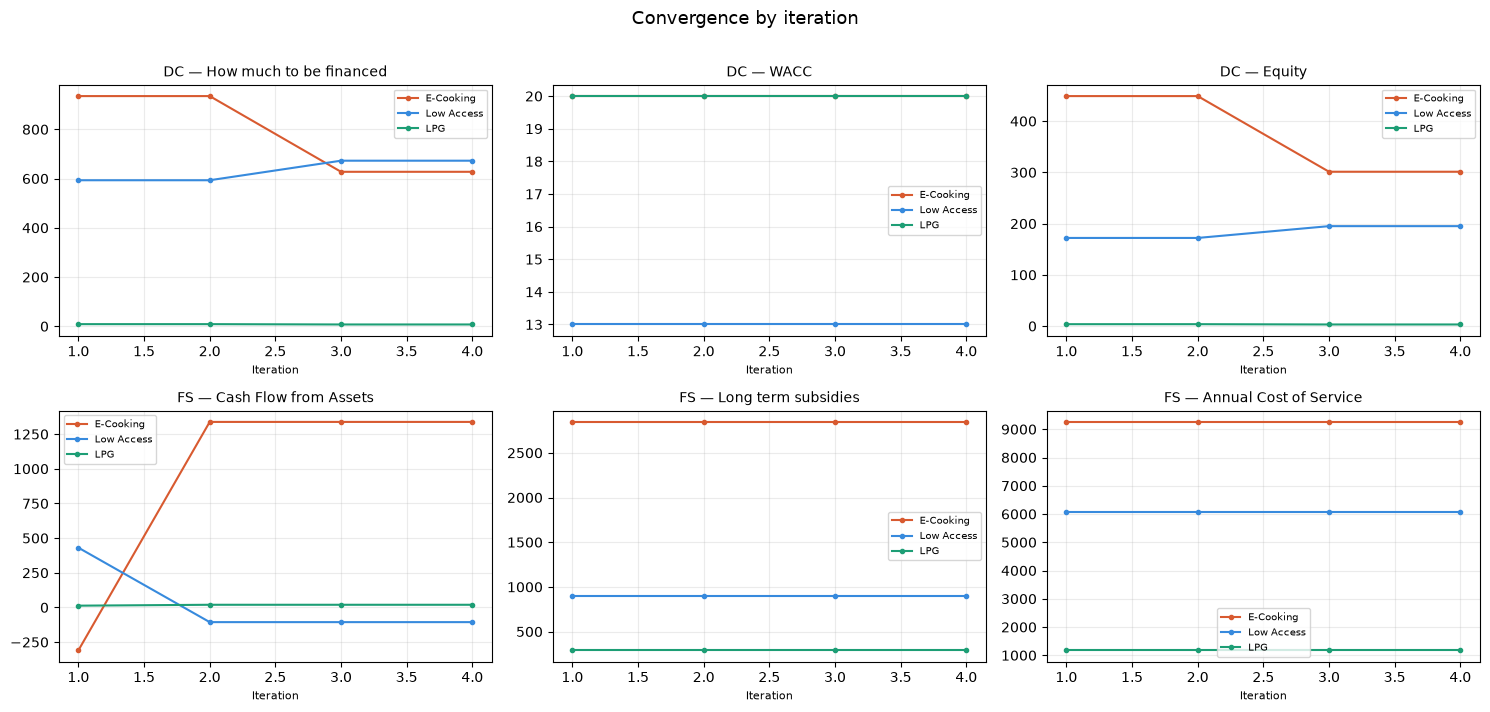

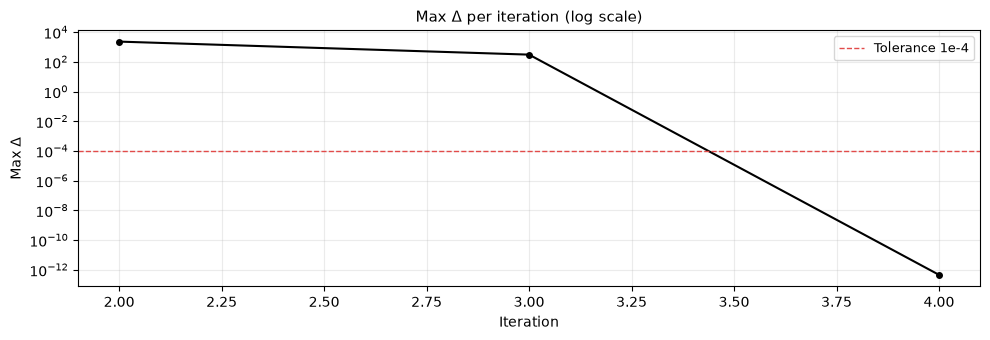

In [9]:
pio.plot_convergence(df_conv)

### Debt requirements

The platform calculates the annual debt needed to cover negative cash positions. 
Review below and optionally inject it back into the model before re-running.

In [10]:
print("=== REQUIRED DEBT PER TECHNOLOGY ===")
REQUIRED_DEBT = {}
for SHEET in pio.get_expanded_sheets():
    req = pio.read_required_debt(SHEET)
    REQUIRED_DEBT[SHEET] = req
    print(f"\n{SHEET}")
    print("  " + "".join(f"{y:>10}" for y in YEARS))
    print("  " + "".join(f"{round(v,1):>10}" for v in req))

=== REQUIRED DEBT PER TECHNOLOGY ===

Electricity & E-Cooking
        2023      2024      2025      2026      2027      2028      2029      2030      2031      2032      2033      2034
         0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0

Electricity (Low access)
        2023      2024      2025      2026      2027      2028      2029      2030      2031      2032      2033      2034
         0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0

LPG
        2023      2024      2025      2026      2027      2028      2029      2030      2031      2032      2033      2034
         0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0


In [11]:
USE_REQUIRED_DEBT = False   # True = automatically inject platform-calculated debt
DEBT_OVERRIDE     = None   # Or: {'Electricity & E-Cooking': [0, 34, 96, 0, ...]}
MAX_DEBT_ITER     = 8 
DEBT_TOL          = 0.5

accumulated = {
    sheet: list(CAPITAL_STRUCTURE[sheet].get('DEBT_INCREASE', [0]*len(YEARS)))
    for sheet in pio.get_expanded_sheets()
}

if DEBT_OVERRIDE:
    for sheet, vals in DEBT_OVERRIDE.items():
        accumulated[sheet] = list(vals)

if USE_REQUIRED_DEBT or DEBT_OVERRIDE:
    print("=== DEBT CONVERGENCE LOOP ===")
    df_conv2 = None
    for debt_iter in range(MAX_DEBT_ITER):
        total_needed = 0
        for sheet in pio.get_expanded_sheets():
            req = pio.read_required_debt(sheet)
            total_needed += sum(req)
            for t, v in enumerate(req):
                if t < len(accumulated[sheet]):
                    accumulated[sheet][t] += v

        print(f"  Iter {debt_iter+1}: remaining debt needed = {total_needed:.2f} M$")

        if total_needed < DEBT_TOL:
            print(f"  Converged in {debt_iter+1} iteration(s).")
            break

        for sheet, vals in accumulated.items():
            pio.write_design_debt_list(sheet, vals)
            CAPITAL_STRUCTURE[sheet]['DEBT_INCREASE'] = vals

        df_conv2 = pio.run_engine_until_convergence(max_iter=30, tol=1e-2)
    else:
        print(f"  Warning: did not converge after {MAX_DEBT_ITER} iterations.")

    if df_conv2 is not None:
        display(df_conv2)

    print("\n=== FINAL INJECTED DEBT PER TECHNOLOGY ===")
    for sheet, vals in accumulated.items():
        print(f"\n{sheet}")
        print("  " + "".join(f"{y:>10}" for y in YEARS))
        print("  " + "".join(f"{round(v,1):>10}" for v in vals))
else:
    print("No debt injection applied.")

No debt injection applied.


## 6. Outputs

In [12]:
col_w = 10
for SHEET in pio.get_expanded_sheets():
    out = pio.read_outputs(SHEET)
    if not out:
        continue
    print(f"\n{'='*70}")
    print(f"  {SHEET}")
    print('='*70)
    header = f"{'Row':<35}" + ''.join(f"{y:>{col_w}}" for y in YEARS)
    print(header)
    print('-' * len(header))
    for key, values in out.items():
        print(f"{key:<35}" + ''.join(f"{round(v,1):>{col_w}}" for v in values))
    check_vals = out.get('Check', [0]*len(YEARS))
    if any(abs(v) > 1 for v in check_vals):
        print(f"\n  ⚠  Balance sheet check FAILED: {[round(v,1) for v in check_vals]}")
    else:
        print(f"\n  ✓  Balance sheet OK")


  Electricity & E-Cooking
Row                                      2023      2024      2025      2026      2027      2028      2029      2030      2031      2032      2033      2034
-----------------------------------------------------------------------------------------------------------------------------------------------------------
Long term subsidies                         0      12.8      66.3     130.3      71.8     210.6     276.7     321.9     493.0     415.0     431.1     416.1
EBITDA                                  291.7     365.6     449.5     521.6     662.9     659.2     771.6     685.6     697.9     877.2     940.1    1001.3
Net Income                              241.0     299.5     366.4     427.8     504.8     532.7     628.5     520.4     568.5     667.1     708.4     742.3
Annual Cost of Service                  240.5     332.2     438.1     530.6     702.2     710.2     824.6     929.8     937.9    1135.0    1204.4    1273.5
Check                                

In [13]:
# === COMPARISON: PYOMO vs PLATFORM ===
col_w = 9

k1_annual = [cs['TARIFF_INCOME'][t] / cs['CAPEX_SCHEDULE'][t] 
             if cs['CAPEX_SCHEDULE'][t] != 0 else 0 
             for t in range(len(YEARS))]
print("  K1 anual: " + ''.join(f"{round(v,3):>9}" for v in k1_annual))

COMP_VARS = [
    ('Tariff Income',        'TARIFF_INCOME',        'Annual Cost of Service'),  # plataforma no tiene tariff directo, usamos ACoS como proxy
    ('Grants',               'GRANTS_PYOMO',         'GRANTS:- Realisation'),
    ('LT Subsidies',         'LT_SUBSIDY_SCHEDULE',  'Long term subsidies'),
    ('Revenues',             'REVENUES_PYOMO',        None),
    ('Costs',                'COSTS_PYOMO',           None),
    ('EBITDA',               'EBITDA_PYOMO',          'EBITDA'),
    ('ACoS',                 None,                    'Annual Cost of Service'),  # añadir ACoS plataforma
    ('Financial Expenses',   'FINANCIAL_EXP_PYOMO',   'Financial Expense'),
    ('CFA',                  'CFA_PYOMO',             'Cash Flow from Assets'),
    ('Debt Increase',        'DEBT_INCREASE',         'DEBT:+ Increase'),
    ('CAPEX (Pyomo)',        'CAPEX_SCHEDULE',         None),
    ('ACoS', 'ACOS_PYOMO', 'Annual Cost of Service'),
]

for sheet in pio.get_expanded_sheets():
    cs  = CAPITAL_STRUCTURE[sheet]
    out = pio.read_outputs(sheet)

    print(f"\n{'='*80}")
    print(f"  {sheet}  —  K1={cs['K1']:.3f}, K2={cs['K2']:.3f}")
    print(f"{'='*80}")

    # CAPEX real del technoeconomic (plataforma)
    if sheet == 'LPG':
        capex_real = TECHNO_LPG.get('CAPEX - Growth', [0]*len(YEARS))
    else:
        g  = TECHNO_ELEC[sheet].get('GRID',     {}).get('CAPEX - Growth', [0]*len(YEARS))
        og = TECHNO_ELEC[sheet].get('OFF-GRID', {}).get('CAPEX - Growth', [0]*len(YEARS))
        capex_real = [g[t]+og[t] for t in range(len(YEARS))]

    print("  CAPEX Platform: " + ''.join(f"{round(v,1):>9}" for v in capex_real))
    print("  CAPEX Pyomo:    " + ''.join(f"{round(v,1):>9}" for v in cs['CAPEX_SCHEDULE']))
    print()

    print(f"{'Variable':<25} {'Source':<10}" + ''.join(f"{y:>{col_w}}" for y in YEARS) + f"{'TOTAL':>{col_w}}")
    print('-'*80)

    for name, pyomo_key, platform_key in COMP_VARS:
        if pyomo_key and pyomo_key in cs:
            vals = cs[pyomo_key]
            tot  = round(sum(vals), 1)
            print(f"{name:<25} {'Pyomo':<10}" + ''.join(f"{round(v,1):>{col_w}}" for v in vals) + f"{tot:>{col_w}}")
        if platform_key and platform_key in out:
            vals = out[platform_key]
            tot  = round(sum(vals), 1)
            print(f"{'':<25} {'Platform':<10}" + ''.join(f"{round(v,1):>{col_w}}" for v in vals) + f"{tot:>{col_w}}")
        if pyomo_key or platform_key:
            print()

  K1 anual:         0        0        0    20.45   38.371   12.579   14.205    8.024    8.045   14.923   17.363   14.699

  Electricity & E-Cooking  —  K1=0.267, K2=0.068
  CAPEX Platform:     296.8    374.9    371.2    367.5    363.8    360.2    397.4    434.0    429.7    425.3    421.1    289.1
  CAPEX Pyomo:        207.7    251.4    295.8    310.8    263.3    416.8    857.5    307.7    341.0    377.1    416.5    485.3

Variable                  Source         2023     2024     2025     2026     2027     2028     2029     2030     2031     2032     2033     2034    TOTAL
--------------------------------------------------------------------------------
Tariff Income             Pyomo         309.9    341.3    376.0    390.2    425.8    470.5    541.1    585.4    633.3    685.2    741.7    837.2   6337.6
                          Platform      240.5    332.2    438.1    530.6    702.2    710.2    824.6    929.8    937.9   1135.0   1204.4   1273.5   9259.3

Grants                    Pyom

## 7. Summary metrics

In [14]:
for SHEET in pio.get_expanded_sheets():
    out = pio.read_outputs(SHEET)
    if not out:
        continue

    lts      = out.get('Long term subsidies',  [0]*len(YEARS))
    equity   = out.get('Equity - EoP',         [0]*len(YEARS))
    debt_eop = out.get('DEBT:EoP',             [0]*len(YEARS))
    grants   = out.get('GRANTS:- Realisation', [0]*len(YEARS))

    _wb = _xl.load_workbook(pio.design_cap_path, data_only=True)
    _ws = _wb[SHEET]
    wacc = next(
        (row[2].value for row in _ws.iter_rows(max_col=3) if row[0].value == 'WACC'),
        None
    )
    _wb.close()

    total_lts    = round(sum(lts), 1)
    total_grants = round(sum(abs(v) for v in grants), 1)
    peak_equity  = round(max(equity), 1)
    peak_debt    = round(max(abs(v) for v in debt_eop), 1)

    print(f"\n{SHEET}")
    print(f"  WACC:               {wacc:.2f}%")
    print(f"  Total LTS:          {total_lts} M$")
    print(f"  Total grants:       {total_grants} M$")
    print(f"  Peak equity (EoP):  {peak_equity} M$")
    print(f"  Peak debt (EoP):    {peak_debt} M$")


Electricity & E-Cooking
  WACC:               20.00%
  Total LTS:          2845.8 M$
  Total grants:       1139.3 M$
  Peak equity (EoP):  5238.7 M$
  Peak debt (EoP):    0 M$

Electricity (Low access)
  WACC:               13.00%
  Total LTS:          897.1 M$
  Total grants:       743.6 M$
  Peak equity (EoP):  3501.0 M$
  Peak debt (EoP):    0.0 M$

LPG
  WACC:               20.00%
  Total LTS:          290.8 M$
  Total grants:       20.8 M$
  Peak equity (EoP):  39.1 M$
  Peak debt (EoP):    0.0 M$


## 8. AI Layer — RL Optimisation + LLM

In [15]:
from rl_agent import run_rl_optimization
from llm_layer import explain_results

### 8.1 RL Optimisation

In [16]:
N_ROUNDS           = 5
N_TRIALS_PER_ROUND = 20

RL_RESULTS   = {}
RL_HISTORIES = {}

for tech, tech_dict in TECHNO_ELEC.items():
    print(f"\n=== RL: {tech} ===")
    best, history = run_rl_optimization(
        tech_dict=tech_dict,
        tax_rate=TAX_RATE,
        years=YEARS,
        initial_ranges=SEARCH_RANGES,
        fuel_fin=FUEL_FIN,
        fuel_key='Electricity',
        objective=OBJECTIVE,
        n_rounds=N_ROUNDS,
        n_trials_per_round=N_TRIALS_PER_ROUND,
        tariffs=TARIFFS,
    )
    RL_RESULTS[tech] = best
    RL_HISTORIES[tech] = history

print("\n=== RL: LPG ===")
best, history = run_rl_optimization(
    tech_dict={'GRID': TECHNO_LPG},
    tax_rate=TAX_RATE,
    years=YEARS,
    initial_ranges=SEARCH_RANGES,
    fuel_fin=FUEL_FIN,
    fuel_key='LPG',
    objective=OBJECTIVE,
    n_rounds=N_ROUNDS,
    n_trials_per_round=N_TRIALS_PER_ROUND,
    tariffs=TARIFFS,
)
RL_RESULTS['LPG'] = best
RL_HISTORIES['LPG'] = history


=== RL: Electricity & E-Cooking ===

── RL Round 1/5 ──
K1=0.27, K2=0.068
Trial 0: total debt=0, debt=[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], capex=[200.31031485424072, 241.99196627064208, 284.1067954023881, 297.8856009182739, 350.0324936834434, 404.7509854305238, 515.8081097761649, 539.4138416717867, 322.1602410722305, 429.8508262628593, 414.43616981810595, 530.2526548393413], lt_subsidies=[0, 0, 0, 0, 0, 0, 26.054573291056865, 0, 0, 54.38282099272993, 0, 44.75854319166547]
Trial 1: total debt=0, debt=[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], capex=[249.6466944968782, 305.6311528502967, 363.5906525952206, 386.719497331807, 460.43983729562996, 540.0925359320439, 276.0725324395943, 306.7987061943523, 340.0392303416202, 376.1004858789783, 440.54400126133663, 485.3246733822409], lt_subsidies=[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 23.995581640742444, 0]
Trial 2: total debt=8e+01, debt=[0, 0, 0, 0, 0, -3.4165976082597018e-12, 0, 77.42612324865925, 0, 0, 0, 0], capex=[217.7634655944523, 241.4719993216464

### 8.2 Write RL results and re-run engine

In [17]:
for sheet, cs in RL_RESULTS.items():
    if cs is None:
        continue
    pio.write_excel_scalar(pio.design_cap_path, sheet, '1. Equity',           cs['PCT_EQUITY'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, 'Cost of Equity',      cs['COST_OF_EQUITY'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, '2. Grants',           cs['PCT_GRANTS'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, 'Years realisation',   cs['YEARS_REALISATION'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, 'Cost of Debt',        cs['COST_OF_DEBT'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, 'Grace period',        cs['GRACE_PERIOD'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, 'Amortization period', cs['AMORTIZATION'])
    pio.write_design_debt_list(sheet, cs['DEBT_INCREASE'])

df_rl = pio.run_engine_until_convergence(max_iter=30, tol=1e-2)
display(df_rl)

  design-capital-CleanStep.xlsx / Electricity & E-Cooking -> 1. Equity = 26
  design-capital-CleanStep.xlsx / Electricity & E-Cooking -> Cost of Equity = 11
  design-capital-CleanStep.xlsx / Electricity & E-Cooking -> 2. Grants = 58
  design-capital-CleanStep.xlsx / Electricity & E-Cooking -> Years realisation = 8
  design-capital-CleanStep.xlsx / Electricity & E-Cooking -> Cost of Debt = 11
  design-capital-CleanStep.xlsx / Electricity & E-Cooking -> Grace period = 2
  design-capital-CleanStep.xlsx / Electricity & E-Cooking -> Amortization period = 30
  design-capital / Electricity & E-Cooking -> User-defined debt increase
  design-capital-CleanStep.xlsx / Electricity (Low access) -> 1. Equity = 27
  design-capital-CleanStep.xlsx / Electricity (Low access) -> Cost of Equity = 15
  design-capital-CleanStep.xlsx / Electricity (Low access) -> 2. Grants = 54
  design-capital-CleanStep.xlsx / Electricity (Low access) -> Years realisation = 8
  design-capital-CleanStep.xlsx / Electricity (L

,iteration,DC::Electricity & E-Cooking::How much to be financed,DC::Electricity & E-Cooking::Equity,DC::Electricity & E-Cooking::Grants,DC::Electricity & E-Cooking::Debt,DC::Electricity & E-Cooking::WACC,DC::Electricity (Low access)::How much to be financed,DC::Electricity (Low access)::Equity,DC::Electricity (Low access)::Grants,DC::Electricity (Low access)::Debt,...,FS::Electricity & E-Cooking::Cash Flow from Assets,FS::LPG::Long term subsidies,FS::LPG::Annual Cost of Service,FS::LPG::Operating Cash Flow,FS::LPG::Cash Flow from Assets,FS::Electricity (Low access)::Long term subsidies,FS::Electricity (Low access)::Annual Cost of Service,FS::Electricity (Low access)::Operating Cash Flow,FS::Electricity (Low access)::Cash Flow from Assets,max_delta
0,1,627.614415,163.179748,364.016361,0.0,11.0,708.511068,191.297988,382.595977,0.0,...,1338.007528,281.826643,1167.907643,62.262667,19.262667,1249.903374,6442.613409,3276.786520,-105.913480,NaN
1,2,627.614415,163.179748,364.016361,0.0,11.0,708.511068,191.297988,382.595977,0.0,...,-736.577791,281.826643,1167.907643,53.299319,10.299319,1249.903374,6442.613409,3629.542851,246.842851,2612.095566
2,3,1106.343197,287.649231,641.679054,0.0,11.0,628.898491,169.802593,339.605185,0.0,...,-736.577791,282.583506,1168.664506,53.299319,10.299319,1249.903374,6442.613409,3629.542851,246.842851,478.728782
3,4,1106.343197,287.649231,641.679054,0.0,11.0,628.898491,169.802593,339.605185,0.0,...,-736.577791,282.583506,1168.664506,54.056182,11.056182,1249.903374,6442.613409,3629.542851,246.842851,0.756863
4,5,1106.343197,287.649231,641.679054,0.0,11.0,628.898491,169.802593,339.605185,0.0,...,-736.577791,282.521353,1168.602353,54.056182,11.056182,1249.903374,6442.613409,3629.542851,246.842851,0.188817
5,6,1106.343197,287.649231,641.679054,0.0,11.0,628.898491,169.802593,339.605185,0.0,...,-736.577791,282.521353,1168.602353,53.994029,10.994029,1249.903374,6442.613409,3629.542851,246.842851,0.062153
6,7,1106.343197,287.649231,641.679054,0.0,11.0,628.898491,169.802593,339.605185,0.0,...,-736.577791,282.526529,1168.607529,53.994029,10.994029,1249.903374,6442.613409,3629.542851,246.842851,0.015505
7,8,1106.343197,287.649231,641.679054,0.0,11.0,628.898491,169.802593,339.605185,0.0,...,-736.577791,282.526529,1168.607529,53.999205,10.999205,1249.903374,6442.613409,3629.542851,246.842851,0.005176


### 8.3 LLM Explanation

In [24]:
from dotenv import load_dotenv
load_dotenv(override=True)

outputs_rl = {sheet: pio.read_outputs(sheet) for sheet in pio.get_expanded_sheets()}

pattern_results = {}
for sheet in pio.get_expanded_sheets():
    cs = RL_RESULTS.get(sheet) or {}
    lts_sched  = cs.get('LT_SUBSIDY_SCHEDULE', [0]*len(YEARS))
    debt_sched = cs.get('DEBT_INCREASE',        [0]*len(YEARS))
    total_lts  = cs.get('TOTAL_LT_SUBSIDIES',   0)
    pattern_results[sheet] = {
        'subsidy_dependent': min(total_lts / 5000, 1.0),
        'fragile_structure': sum(1 for v in debt_sched if v > 0) / len(YEARS),
        'high_circularity':  0.0,
    }

explanation = explain_results(pattern_results, outputs_rl, YEARS, COUNTRY, language='en', model='openai/gpt-oss-20b')
print(explanation)

The optimisation shows that the Electricity & E‑Cooking and Low‑Access electricity projects can be financed with zero debt and retain healthy cash buffers (≈ 240 M$ and 143 M$ respectively), yet their high annual operating costs (~ 580 M$/yr and ~ 537 M$/yr) signal a potential subsidy‑dependency risk if tariff revenues fall short.  The LPG option, while the cheapest at ~ 97 M$/yr, already pushes the cash flow marginally negative (‑0.2 M$) and carries a small peak debt of 0.3 M$, exposing a fragile structure if the modest debt were to grow.  Overall, the lack of flagged solver convergence issues suggests the models are robust, but the financing plan should prioritize equity or grant support for the high‑cost electricity schemes and consider debt‑equity structuring for LPG to avoid cash shortfalls.


### 8.4 Chat con el asesor IA

In [35]:
from dotenv import load_dotenv
load_dotenv(override=True)
from groq import Groq

capex_lines = []
for sheet in pio.get_expanded_sheets():
    cs = RL_RESULTS.get(sheet) or {}
    capex = cs.get('CAPEX_SCHEDULE', [])
    tariff = cs.get('TARIFF_INCOME', [])
    capex_lines.append(
        f"- {sheet}: CAPEX total={round(sum(capex),1)} M$, "
        f"tariff income total={round(sum(tariff),1)} M$, "
        f"optimal equity={cs.get('PCT_EQUITY','?')}%, "
        f"optimal grants={cs.get('PCT_GRANTS','?')}%, "
        f"cost_debt={cs.get('COST_OF_DEBT','?')}%, "
        f"amortization={cs.get('AMORTIZATION','?')} years"
    )
context_data = "\n".join(capex_lines)

system_prompt = f"""You are a senior investment advisor specialising in clean energy infrastructure financing in sub-Saharan Africa.

You are advising on the CleanStep scenario for {COUNTRY} ({YEARS[0]}-{YEARS[-1]}).

Key financial results from AI optimisation:
{explanation}

Your role is to propose financing structures, estimate viable debt interest rate ranges for negotiation, and flag liquidity risks. Be quantitative. Respond in the same language as the user."""

client = Groq()
conversation = [{"role": "system", "content": system_prompt}]

print("Chat con el asesor de inversión (escribe 'salir' para terminar):\n")
while True:
    user_input = input("Tú: ").strip()
    if user_input.lower() in ('salir', 'exit', 'quit', ''):
        break
    conversation.append({"role": "user", "content": user_input})
    response = client.chat.completions.create(
        model='openai/gpt-oss-20b',
        messages=conversation,
        max_tokens=2000,
    )
    reply = response.choices[0].message.content or ""
    conversation.append({"role": "assistant", "content": reply})
    print(f"\nAsistente: {reply}\n")

Chat con el asesor de inversión (escribe 'salir' para terminar):


Asistente: ## 1. Resumen del plan financiero (15 años)

| Elemento | Valor | Comentario |
|----------|-------|------------|
| **CAPEX total** | **US $1 000 M** | 800 M$ (Electricity + E‑Cooking + Low‑Access) + 200 M$ (LPG) |
| **Grants** | 10 % × CAPEX = **US $100 M** | No reembolsable; cubre parte de CAPEX en los 5 años iniciales |
| **CAPEX neto a financiar** | 900 M$ | 1 000 M$ – 100 M$ |
| **Equity (25 %)** | 225 M$ | Coste = 16 % (valor de mercado) |
| **Deuda (75 %)** | 675 M$ | Coste = 5 % nominal, 3 años de carencia, amortización 12 años |
| **Plazo total** | 15 años | 3 años de carencia + 12 años de amortización |
| **Tasa de interés negociable** | **4‑6 %** | Se recomienda rango 5 % (benchmark) con posibilidad de 4 % si se negocia un crédito bancario de desarrollo |
| **Flujo operativo neto (tarifas – OPEX)** | -US $ 14 M/yr (promedio) | OPEX ≈ 1 214 M$/yr; ingresos estimados 1 200 M$/yr → déficit ≈ 14 M$/yr |

con un equity del 25%, coste de equity 16%, coste de deuda 5%, carencia 3 años, grants 10% del CAPEX durante 5 años — ¿qué plan financiero a 15 años propones?